In [ ]:
import pandas as pd
from sklearn.datasets import load_wine

df = load_wine()

In [ ]:
df.keys()

dict_keys(['data', 'target', 'target_names', 'DESCR', 'feature_names'])

In [ ]:
df['feature_names']

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [ ]:
X = pd.DataFrame(df['data'],columns=df['feature_names'])

In [ ]:
df['target_names']

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [ ]:
Y = df['target']

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X,Y)

In [ ]:
print(X.shape)
print(Y.shape)
print(xtrain.shape)
print(xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(178, 13)
(178,)
(133, 13)
(45, 13)
(133,)
(45,)


In [ ]:
#Import Algorithm and declare model to be trained
from sklearn.tree import DecisionTreeClassifier
dmodel = DecisionTreeClassifier(max_leaf_nodes=4)

In [ ]:
#Train Your model
dmodel.fit(xtrain,ytrain)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=4,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

In [ ]:
dmodel.score(xtrain,ytrain)

0.9849624060150376

In [ ]:
dmodel.score(xtest,ytest)

0.8666666666666667

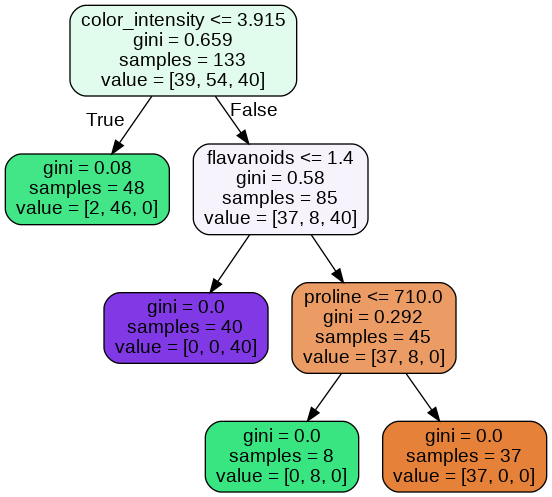

In [ ]:
#plotting the tree created by decision tree classifier
from sklearn.tree import export_graphviz
dot_data = export_graphviz(dmodel,feature_names=xtrain.columns,filled=True,rounded=True)

from IPython.display import Image
import pydotplus

graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(ytest,dmodel.predict(xtest))

array([[16,  4,  0],
       [ 0, 17,  0],
       [ 0,  2,  6]])

In [ ]:
from sklearn.model_selection import cross_val_score
print(cross_val_score(dmodel,xtrain,ytrain,cv=5))

[0.92592593 0.96296296 0.88888889 1.         0.88461538]


In [ ]:
print(cross_val_score(dmodel,xtest,ytest,cv=5))

[0.55555556 0.88888889 0.88888889 1.         1.        ]


In [ ]:
dfl = pd.read_csv('/content/Loan Approval Prediction.csv')
dfl.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
